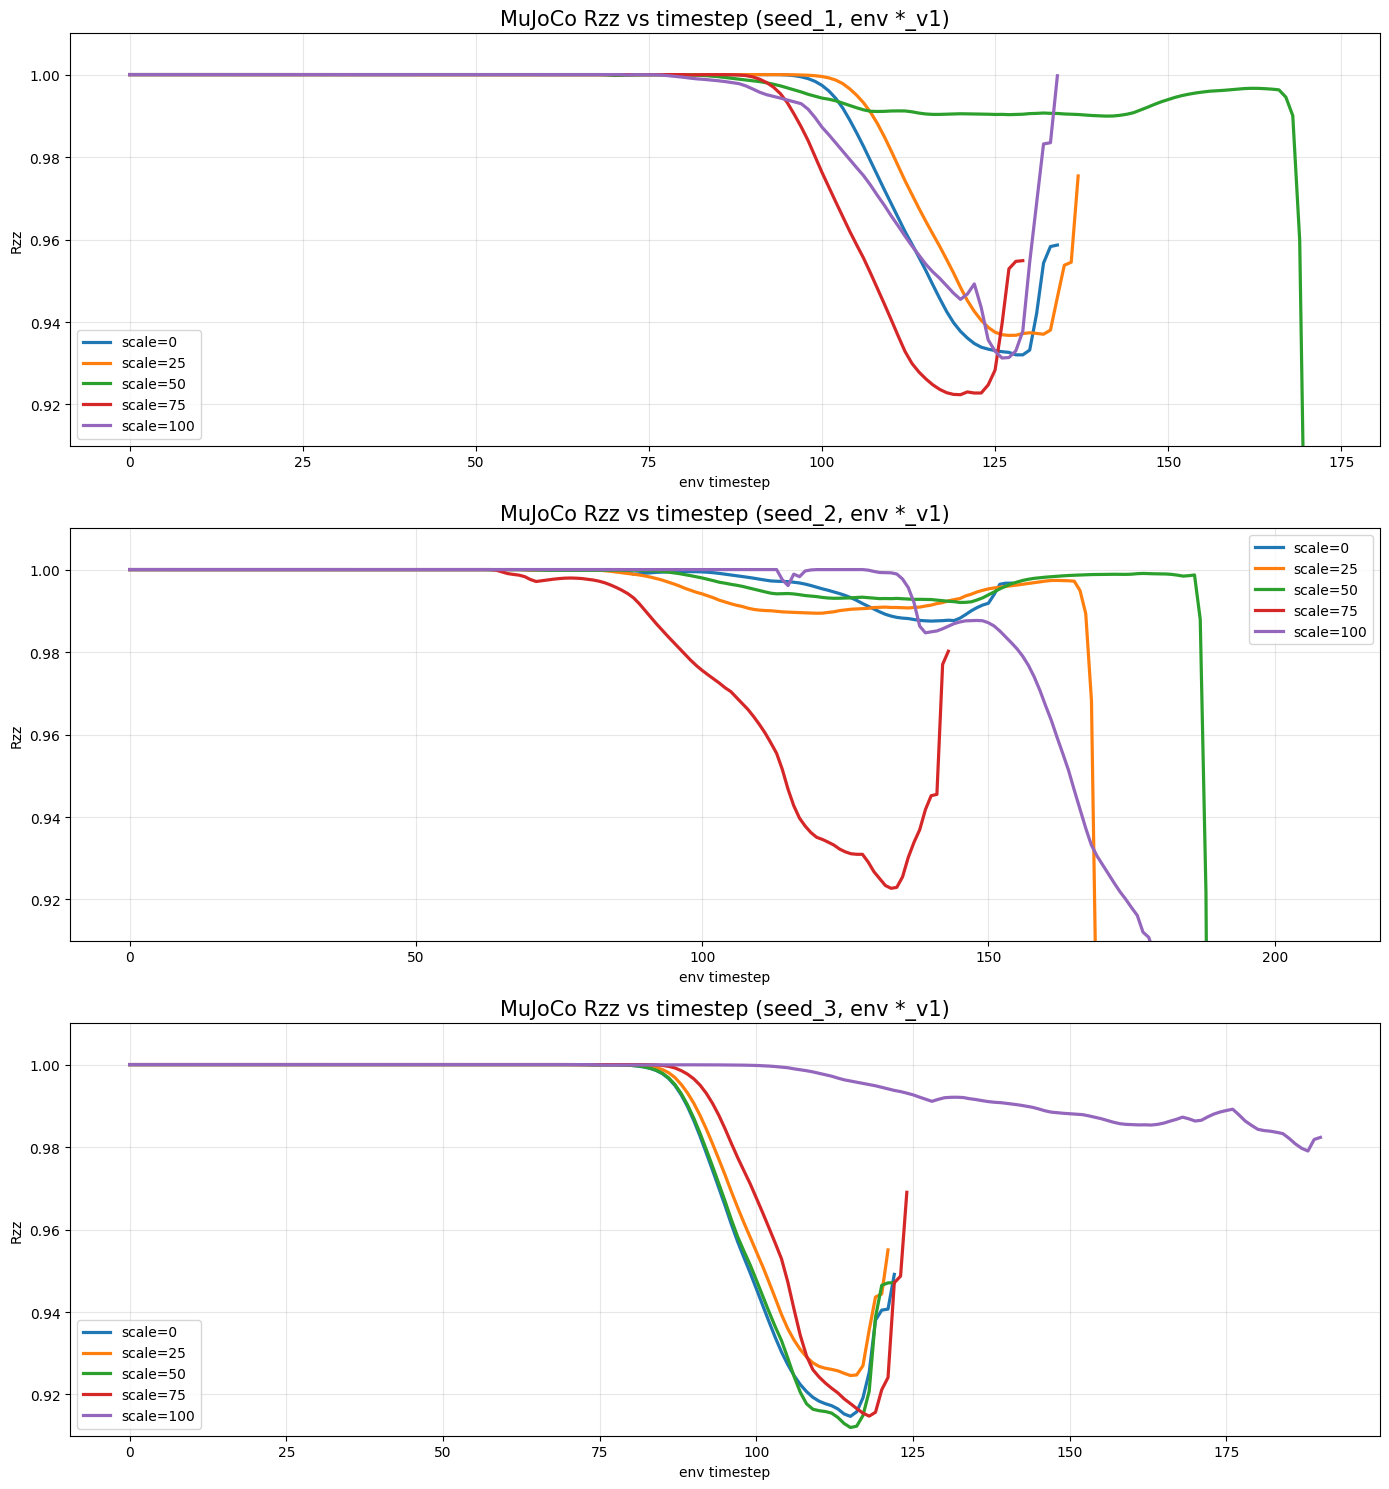

available seeds: [1, 2, 3]
missing seeds: []
seed 1: ['scale=0', 'scale=25', 'scale=50', 'scale=75', 'scale=100'] | init_name: n16h300r60g1bYfYv1
seed 2: ['scale=0', 'scale=25', 'scale=50', 'scale=75', 'scale=100'] | init_name: n16h300r60g1bYfYv1
seed 3: ['scale=0', 'scale=25', 'scale=50', 'scale=75', 'scale=100'] | init_name: n16h300r60g1bYfYv1
run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101
Note: scale=10 is included only if dp_guidance_l10 exists in this run.


In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- Config: same env used in guidance/diffusion_guidance.ipynb ---
RUN_ROOT_REL = Path("outputs/can_rollouts/comparison/20260404_171101")
TARGET_SEEDS = [1, 2, 3]
TARGET_INIT_NAME = "n16h300r60g1bYfYv1"  # exact env init from diffusion_guidance.ipynb
TARGET_INIT_SUFFIX = "v1"

# Map method folder -> guidance scale label for plotting
METHOD_SCALE_MAP = {
    "dp_base": 0,
    "dp_guidance_l10": 10,   # optional (not present in current comparison run)
    "dp_guidance_l25": 25,
    "dp_guidance_l50": 50,
    "dp_guidance_l75": 75,
    "dp_guidance_l100": 100,
}


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "experiments").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from: {start}")


def _read_rows(rows_path: Path):
    rows = []
    if not rows_path.exists():
        return rows
    with rows_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def _load_seed_series(run_root: Path, repo_root: Path, seed: int):
    series = []
    for method_slug, scale in sorted(METHOD_SCALE_MAP.items(), key=lambda kv: kv[1]):
        rows_path = run_root / method_slug / "rollout_rows.jsonl"
        rows = _read_rows(rows_path)
        if not rows:
            continue

        # Match seed + exact init first, then fallback to *_v1 suffix.
        candidates = [
            r for r in rows
            if int(r.get("seed", -1)) == seed
            and str(r.get("init_name", "")) == TARGET_INIT_NAME
        ]
        if not candidates:
            candidates = [
                r for r in rows
                if int(r.get("seed", -1)) == seed
                and str(r.get("init_name", "")).endswith(TARGET_INIT_SUFFIX)
            ]

        if not candidates:
            continue

        row = candidates[0]
        combo_dir = Path(row["combo_dir"])
        if not combo_dir.is_absolute():
            combo_dir = (repo_root / combo_dir).resolve()

        npz_path = combo_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        data = np.load(npz_path)
        if "rzz_mujoco" not in data.files:
            continue

        rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)
        series.append((scale, rzz, method_slug, row.get("init_name", "")))

    series.sort(key=lambda x: x[0])
    return series


repo_root = _find_repo_root(Path.cwd())
run_root = (repo_root / RUN_ROOT_REL).resolve()
if not run_root.exists():
    raise FileNotFoundError(f"Run root not found: {run_root}")

seed_to_series = {}
for seed in TARGET_SEEDS:
    seed_to_series[seed] = _load_seed_series(run_root, repo_root, seed)

available_seeds = [s for s in TARGET_SEEDS if seed_to_series[s]]
missing_seeds = [s for s in TARGET_SEEDS if not seed_to_series[s]]
if not available_seeds:
    raise RuntimeError("No matching rollouts found for requested seed/env filter.")

# Use shared y-axis limits for easier cross-seed comparison.
all_rzz = np.concatenate([rzz for s in available_seeds for _, rzz, _, _ in seed_to_series[s]])
y_min = float(all_rzz.min()) - 0.002
y_max = float(all_rzz.max()) + 0.002

fig, axes = plt.subplots(
    nrows=len(available_seeds),
    ncols=1,
    figsize=(14, 5 * len(available_seeds)),
    sharey=True,
)
if len(available_seeds) == 1:
    axes = [axes]

for ax, seed in zip(axes, available_seeds):
    series = seed_to_series[seed]
    for scale, rzz, method_slug, init_name in series:
        ax.plot(np.arange(len(rzz)), rzz, linewidth=2.3, label=f"scale={scale}")

    ax.set_title(f"MuJoCo Rzz vs timestep (seed_{seed}, env *_v1)", fontsize=15)
    ax.set_xlabel("env timestep")
    ax.set_ylabel("Rzz")
    ax.set_ylim(0.91, 1.01)
    ax.grid(alpha=0.30)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("available seeds:", available_seeds)
print("missing seeds:", missing_seeds)
for seed in available_seeds:
    scales = [f"scale={s}" for s, *_ in seed_to_series[seed]]
    init_name = seed_to_series[seed][0][3]
    print(f"seed {seed}:", scales, "| init_name:", init_name)

print("run root:", run_root)
print("Note: scale=10 is included only if dp_guidance_l10 exists in this run.")

OVERALL MEAN RZZ ACROSS ALL SEEDS & ENVIRONMENTS
Method                                  Mean Rzz      Std Dev      N
------------------------------------------------------------------------------------------
DP Guidance (λ=25)                      0.990453     0.003623     10
DP Guidance (λ=50)                      0.990170     0.004565     10
DP Base                                 0.989465     0.004479     10
DP Guidance (λ=100)                     0.988740     0.007815     10
Sample-and-Rank (k=8)                   0.987674     0.000951     10
DP Guidance (λ=75)                      0.986503     0.004668     10

PER-ENVIRONMENT MEAN RZZ

--- Environment: n16h300r60g1bYfYv1 ---
Method                                  Mean Rzz      N
-------------------------------------------------------
DP Guidance (λ=25)                      0.990453     10
DP Guidance (λ=50)                      0.990170     10
DP Base                                 0.989465     10
DP Guidance (λ=100)           

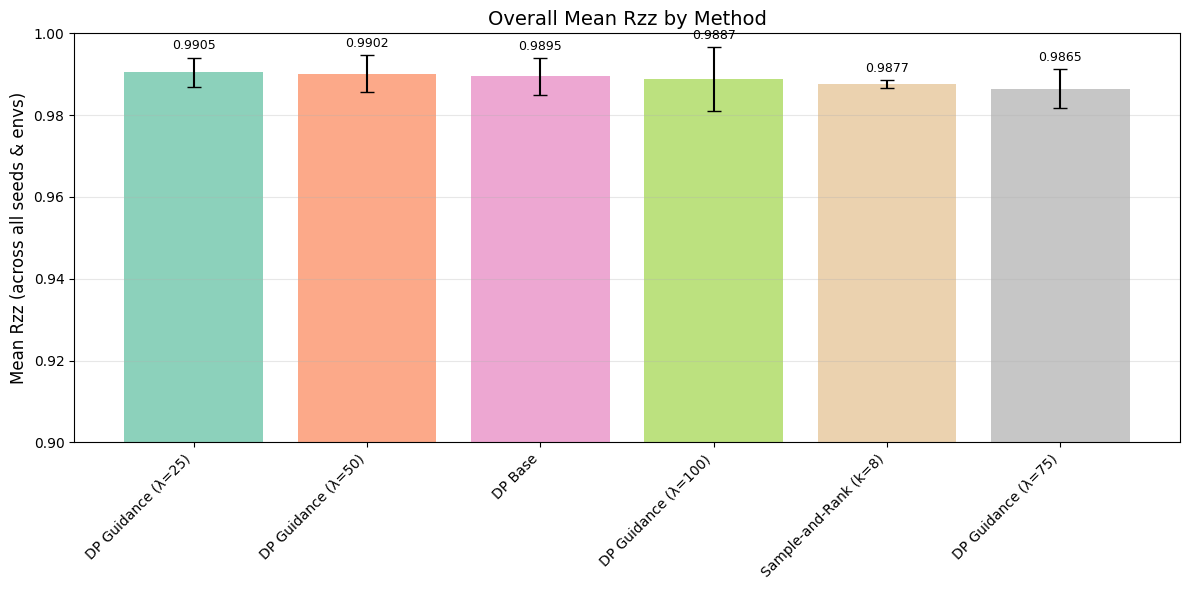


✓ Analysis complete.


In [6]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- Reload config and helper functions ---
RUN_ROOT_REL = Path("outputs/can_rollouts/comparison/20260404_171101")
TARGET_INIT_SUFFIX = "v1"

METHOD_SCALE_MAP = {
    "dp_base": 0,
    "dp_guidance_l10": 10,
    "dp_guidance_l25": 25,
    "dp_guidance_l50": 50,
    "dp_guidance_l75": 75,
    "dp_guidance_l100": 100,
    "snr_k8": "snr_k8",  # sample-and-rank
}

METHOD_LABELS = {
    "dp_base": "DP Base",
    "dp_guidance_l10": "DP Guidance (λ=10)",
    "dp_guidance_l25": "DP Guidance (λ=25)",
    "dp_guidance_l50": "DP Guidance (λ=50)",
    "dp_guidance_l75": "DP Guidance (λ=75)",
    "dp_guidance_l100": "DP Guidance (λ=100)",
    "snr_k8": "Sample-and-Rank (k=8)",
}

def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "experiments").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from: {start}")


def _read_rows(rows_path: Path):
    rows = []
    if not rows_path.exists():
        return rows
    with rows_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


repo_root = _find_repo_root(Path.cwd())
run_root = (repo_root / RUN_ROOT_REL).resolve()

# Aggregate mean Rzz per method, overall and per environment
method_to_rzz_values = defaultdict(list)
method_to_env_rzz = defaultdict(lambda: defaultdict(list))

for method_slug in METHOD_SCALE_MAP.keys():
    rows_path = run_root / method_slug / "rollout_rows.jsonl"
    rows = _read_rows(rows_path)
    
    for row in rows:
        init_name = str(row.get("init_name", ""))
        if not init_name.endswith(TARGET_INIT_SUFFIX):
            continue
        
        mean_rzz = float(row.get("mean_rzz", np.nan))
        if not np.isnan(mean_rzz):
            method_to_rzz_values[method_slug].append(mean_rzz)
            method_to_env_rzz[method_slug][init_name].append(mean_rzz)

# Compute overall averages per method
overall_results = []
for method_slug, rzz_list in sorted(method_to_rzz_values.items()):
    if not rzz_list:
        continue
    mean = np.mean(rzz_list)
    std = np.std(rzz_list)
    count = len(rzz_list)
    label = METHOD_LABELS.get(method_slug, method_slug)
    overall_results.append({
        "slug": method_slug,
        "label": label,
        "mean": mean,
        "std": std,
        "count": count,
    })

# Sort by mean descending (best first)
overall_results.sort(key=lambda x: x["mean"], reverse=True)

print("=" * 90)
print("OVERALL MEAN RZZ ACROSS ALL SEEDS & ENVIRONMENTS")
print("=" * 90)
print(f"{'Method':<35} {'Mean Rzz':>12} {'Std Dev':>12} {'N':>6}")
print("-" * 90)
for r in overall_results:
    print(f"{r['label']:<35} {r['mean']:>12.6f} {r['std']:>12.6f} {r['count']:>6}")
print()

# Per-environment breakdown
print("=" * 90)
print("PER-ENVIRONMENT MEAN RZZ")
print("=" * 90)

all_envs = set()
for method_data in method_to_env_rzz.values():
    all_envs.update(method_data.keys())

for env_name in sorted(all_envs):
    print(f"\n--- Environment: {env_name} ---")
    env_results = []
    for method_slug in sorted(method_to_env_rzz.keys()):
        rzz_list = method_to_env_rzz[method_slug].get(env_name, [])
        if not rzz_list:
            continue
        mean = np.mean(rzz_list)
        count = len(rzz_list)
        label = METHOD_LABELS.get(method_slug, method_slug)
        env_results.append({
            "label": label,
            "mean": mean,
            "count": count,
        })
    
    if env_results:
        env_results.sort(key=lambda x: x["mean"], reverse=True)
        print(f"{'Method':<35} {'Mean Rzz':>12} {'N':>6}")
        print("-" * 55)
        for r in env_results:
            print(f"{r['label']:<35} {r['mean']:>12.6f} {r['count']:>6}")
    else:
        print("  (no data)")

# Quick visualization: bar chart of overall means
fig, ax = plt.subplots(figsize=(12, 6))
methods = [r["label"] for r in overall_results]
means = [r["mean"] for r in overall_results]
stds = [r["std"] for r in overall_results]

colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))
bars = ax.bar(range(len(methods)), means, yerr=stds, capsize=5, color=colors, alpha=0.75)

ax.set_ylabel("Mean Rzz (across all seeds & envs)", fontsize=12)
ax.set_title("Overall Mean Rzz by Method", fontsize=14)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=45, ha="right")
ax.set_ylim([0.9, 1.0])
ax.grid(axis="y", alpha=0.3)

for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.002, f"{mean:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Analysis complete.")
